# Stage 1 — Failed-Subscription Diagnosis: Model Training

Trains a real, evaluated ML classifier to predict **why** a payment failed,
from structured features only (no LLM). This is the model that gives a
defensible answer when a judge asks "what did your AI actually learn?"

Same logic as the original `train_stage1_diagnosis.py` script, split into
cells so each step (load → engineer → split → train → evaluate → save) can
be inspected and rerun independently — this is the notebook/script split
described in `docs/architecture.md` section 7.


In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

DATA_PATH = "../data/failed_payments.csv"
MODELS_DIR = "../models"
OUTPUTS_DIR = "../outputs"
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

FEATURE_COLS = [
    "amount", "hour_of_day", "day_of_week",
    "retry_count_so_far", "past_failure_count", "subscription_age_days",
]
TARGET_COL = "decline_reason_true"


## 1. Load the combined (real + synthetic) dataset
Run `combine_data.py` first if this file doesn't exist yet.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} records")
df.head()


Loaded 1200 records


,payment_id,customer_name,amount,hour_of_day,day_of_week,retry_count_so_far,past_failure_count,subscription_age_days,decline_reason_true,is_soft_decline_true,is_retriable_true
0,PAY00000,Allison Hill,48.56,16,3,2,1,380,risk_fraud_flag,False,False
1,PAY00001,Noah Rhodes,21.48,9,1,1,1,17,insufficient_funds_or_technical,True,True
2,PAY00002,Angie Henderson,16.82,10,5,0,1,119,insufficient_funds_or_technical,True,True
3,PAY00003,Daniel Wagner,56.86,15,1,0,1,556,card_expired,False,False
4,PAY00004,Cristian Santos,10.76,20,5,1,1,214,insufficient_funds_or_technical,True,True


In [3]:
df[TARGET_COL].value_counts()


decline_reason_true
insufficient_funds_or_technical    610
card_expired                       544
risk_fraud_flag                     46
Name: count, dtype: int64

## 2. Feature engineering + train/test split
Honest 80/20 split — the test set is never touched until evaluation.

In [4]:
X = df[FEATURE_COLS].copy()
y_raw = df[TARGET_COL]

label_enc = LabelEncoder()
y = label_enc.fit_transform(y_raw)
class_names = label_enc.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")


Train size: 960  |  Test size: 240


## 3. Train the classifier

In [5]:
use_xgb = True

if use_xgb and HAS_XGB:
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric="mlogloss", random_state=42
    )
    model_name = "XGBoost"
else:
    model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
    model_name = "RandomForest"

model.fit(X_train, y_train)
print(f"Trained: {model_name}")


Trained: XGBoost


## 4. Evaluate on the held-out test set

In [6]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Held-out test accuracy: {acc:.3f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


Held-out test accuracy: 0.775

Classification report:
                                 precision    recall  f1-score   support

                   card_expired       0.81      0.73      0.77       109
insufficient_funds_or_technical       0.75      0.84      0.79       122
                risk_fraud_flag       0.80      0.44      0.57         9

                       accuracy                           0.78       240
                      macro avg       0.79      0.67      0.71       240
                   weighted avg       0.78      0.78      0.77       240



## 5. Confusion matrix

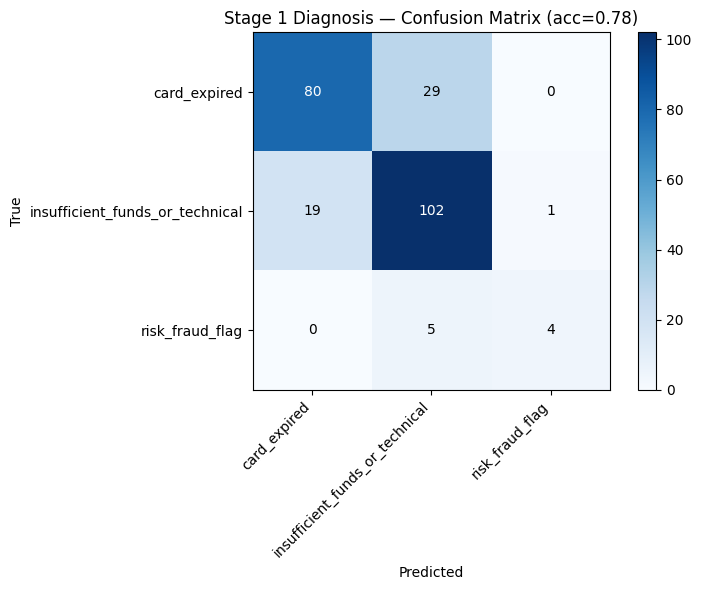

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Stage 1 Diagnosis — Confusion Matrix (acc={acc:.2f})")
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/stage1_confusion_matrix.png", dpi=150)
plt.show()


## 6. Feature importance

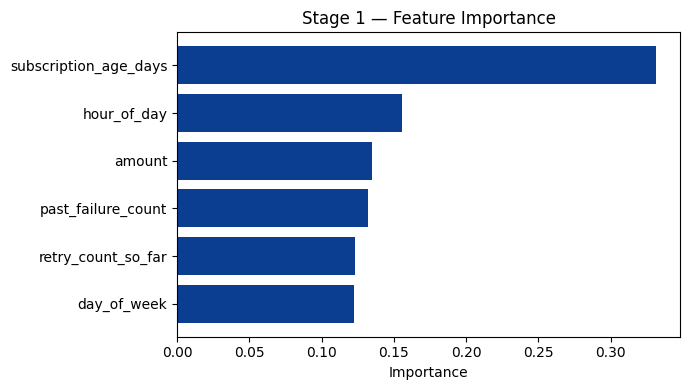

Takeaway: 'subscription_age_days' was the strongest predictor of failure type.


In [8]:
importances = model.feature_importances_
order = np.argsort(importances)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(np.array(FEATURE_COLS)[order], importances[order], color="#0b3d91")
ax.set_title("Stage 1 — Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{OUTPUTS_DIR}/stage1_feature_importance.png", dpi=150)
plt.show()

top_feat = np.array(FEATURE_COLS)[order][-1]
print(f"Takeaway: '{top_feat}' was the strongest predictor of failure type.")


## 7. Save the trained model

This is the file the FastAPI backend loads at `backend/app/stage1_diagnosis/diagnose.py`
— training happens once here, serving happens live in the backend.

In [9]:
model_bundle = {
    "model": model,
    "label_encoder": label_enc,
    "feature_cols": FEATURE_COLS,
}
joblib.dump(model_bundle, f"{MODELS_DIR}/stage1_diagnosis_model.pkl")
print(f"Saved: {MODELS_DIR}/stage1_diagnosis_model.pkl")


Saved: ../models/stage1_diagnosis_model.pkl
